# 🏦 Bank Marketing: Predicting Term Deposit Subscription

**Goal:** Predict whether a customer will subscribe to a term deposit (`yes`/`no`) based on their profile and past marketing campaign interactions, using the classic UCI Bank Marketing dataset.

**What this notebook covers:**
1. Data loading & column understanding
2. Exploratory Data Analysis (EDA)
3. Data leakage detection & handling
4. Data preprocessing & encoding
5. Handling class imbalance
6. Model building (Random Forest, XGBoost, LightGBM, Gradient Boosting)
7. Model comparison & feature importance
8. Conclusion

*Beginner-friendly: every step is explained in plain language before the code.*

## 1. Import Libraries
We import standard libraries for data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and modeling (`scikit-learn`, `xgboost`, `lightgbm`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## 2. Load the Dataset
The raw file has generic column names (`V1`, `V2`, ...). We rename them to their real, meaningful names (this is the well-known **UCI Bank Marketing** dataset) so the analysis is easier to follow.

In [2]:
df = pd.read_csv('Bank_Marketing_Dataset.csv')

column_names = {
    'V1': 'age', 'V2': 'job', 'V3': 'marital', 'V4': 'education',
    'V5': 'default', 'V6': 'balance', 'V7': 'housing', 'V8': 'loan',
    'V9': 'contact', 'V10': 'day', 'V11': 'month', 'V12': 'duration',
    'V13': 'campaign', 'V14': 'pdays', 'V15': 'previous', 'V16': 'poutcome',
    'Class': 'target'
}
df.rename(columns=column_names, inplace=True)

# target: 1 = no, 2 = yes -> convert to 0/1 for standard ML convention
df['target'] = df['target'].map({1: 0, 2: 1})

print("Shape:", df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


**Column meanings:**
- `age`, `job`, `marital`, `education` — customer demographics
- `default`, `balance`, `housing`, `loan` — financial status (credit default, account balance, housing/personal loan)
- `contact`, `day`, `month`, `duration` — details of the last contact in the current campaign
- `campaign`, `pdays`, `previous`, `poutcome` — history of this and previous campaigns
- `target` — did the customer subscribe to a term deposit? (0 = No, 1 = Yes)

## 3. Exploratory Data Analysis (EDA)
First, let's check data types, missing values, and how imbalanced our target is.

In [3]:
print("Missing values:\n", df.isnull().sum().sum(), "total missing cells")
print("\nData types:\n", df.dtypes)
print("\nTarget distribution:")
print(df['target'].value_counts(normalize=True).rename('proportion'))

Missing values:
 0 total missing cells

Data types:
 age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
target       int64
dtype: object

Target distribution:
target
0    0.883015
1    0.116985
Name: proportion, dtype: float64


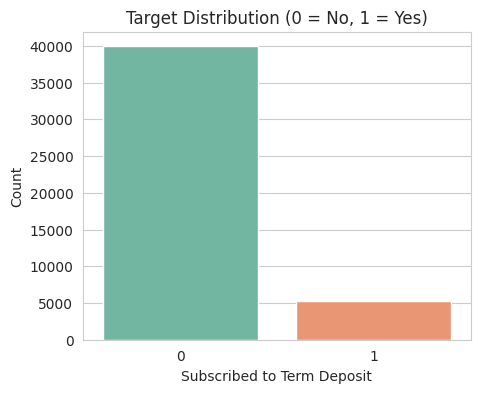

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Target Distribution (0 = No, 1 = Yes)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.show()

📌 **Observation:** The dataset is **imbalanced** — only about 11-12% of customers subscribed. We'll need to account for this when training and evaluating our models (accuracy alone can be misleading here).

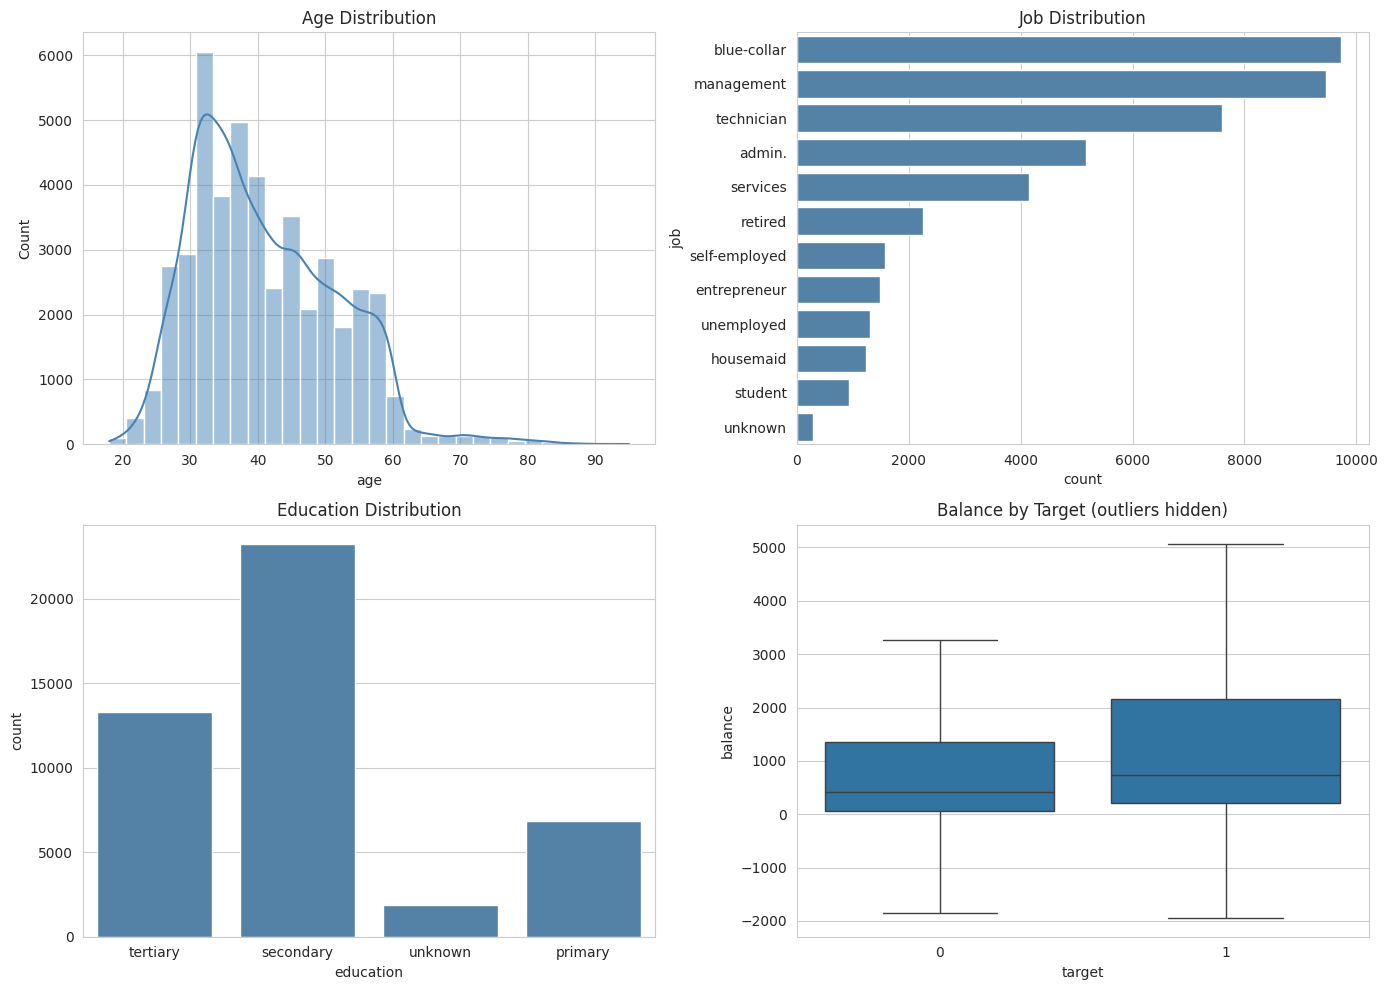

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Age Distribution')

sns.countplot(y='job', data=df, order=df['job'].value_counts().index, ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Job Distribution')

sns.countplot(x='education', data=df, ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Education Distribution')

sns.boxplot(x='target', y='balance', data=df, ax=axes[1,1], showfliers=False)
axes[1,1].set_title('Balance by Target (outliers hidden)')

plt.tight_layout()
plt.show()

## 4. Data Leakage Detection ⚠️
The `duration` column (last contact duration in seconds) is **highly correlated with the target** — naturally, if a call lasts longer, the customer is more likely to say yes. But in a *real-world* scenario, we wouldn't know the call duration **before** making the call, so using it would leak future information into our model and make it look artificially good.

We check the correlation below and then **drop `duration`** to keep our model realistic and deployable.

In [6]:
corr_with_target = df.select_dtypes(include=np.number).corr()['target'].sort_values(ascending=False)
print("Correlation of numeric features with target:\n")
print(corr_with_target)

Correlation of numeric features with target:

target      1.000000
duration    0.394521
pdays       0.103621
previous    0.093236
balance     0.052838
age         0.025155
day        -0.028348
campaign   -0.073172
Name: target, dtype: float64


In [7]:
# Drop duration to avoid data leakage
df_model = df.drop(columns=['duration'])
print("'duration' dropped. Remaining shape:", df_model.shape)

'duration' dropped. Remaining shape: (45211, 16)


## 5. Data Preprocessing
- `pdays = -1` means the customer was never contacted before — we keep it as is since tree-based models handle this fine.
- Categorical columns are label-encoded so models can process them numerically.
- We split data into train/test **before** any encoding leaks info, using stratified sampling to preserve the target ratio.

In [8]:
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = df_model.copy()
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

df_encoded.head()

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,target
0,58,4,1,2,0,2143,1,0,2,5,8,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,1,-1,0,3,0


In [9]:
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target ratio:\n", y_train.value_counts(normalize=True))

Train shape: (36168, 15)  Test shape: (9043, 15)
Train target ratio:
 target
0    0.883018
1    0.116982
Name: proportion, dtype: float64


## 6. Model Building
We train four popular classifiers and compare them. Since the data is imbalanced, we use `class_weight='balanced'` (or the equivalent `scale_pos_weight` for boosting models) so the model pays more attention to the minority ("yes") class.

**Models:** Random Forest, Gradient Boosting, XGBoost, LightGBM

In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        class_weight='balanced', random_state=RANDOM_STATE, verbosity=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LightGBM,0.818534,0.349820,0.641777,0.452818,0.804104
1,Gradient Boosting,0.893619,0.634831,0.213611,0.319661,0.803091
2,XGBoost,0.823510,0.355841,0.627599,0.454172,0.801545
3,Random Forest,0.813447,0.334037,0.598299,0.428717,0.788511


📌 **Why ROC-AUC over Accuracy?** With an imbalanced target (~88% "No"), a model could get ~88% accuracy by just predicting "No" every time — that's meaningless. **ROC-AUC** and **Recall** on the minority class tell us how well the model actually identifies likely subscribers, which is what a marketing team truly cares about.

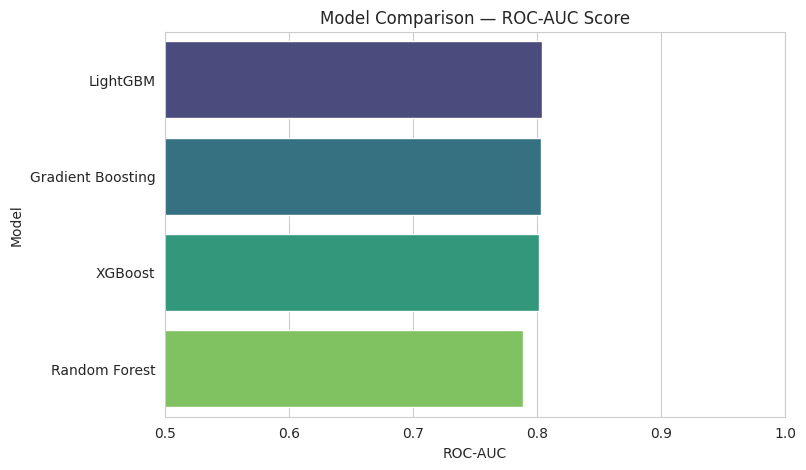

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(x='ROC-AUC', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison — ROC-AUC Score')
plt.xlim(0.5, 1.0)
plt.show()

## 7. Best Model — Detailed Evaluation
Let's look closer at the top-performing model: confusion matrix and full classification report.

Best Model: LightGBM


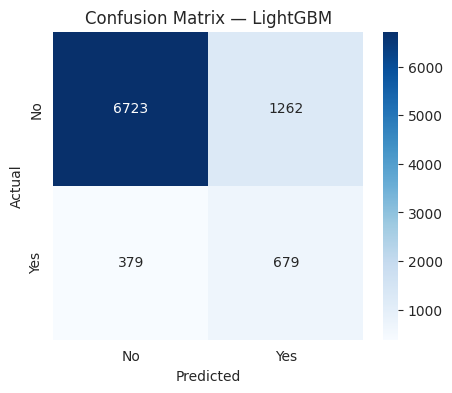

              precision    recall  f1-score   support

          No       0.95      0.84      0.89      7985
         Yes       0.35      0.64      0.45      1058

    accuracy                           0.82      9043
   macro avg       0.65      0.74      0.67      9043
weighted avg       0.88      0.82      0.84      9043



In [12]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['No', 'Yes']))

## 8. Feature Importance
Which features matter most in predicting subscription? Understanding this helps a marketing team focus on the right levers.

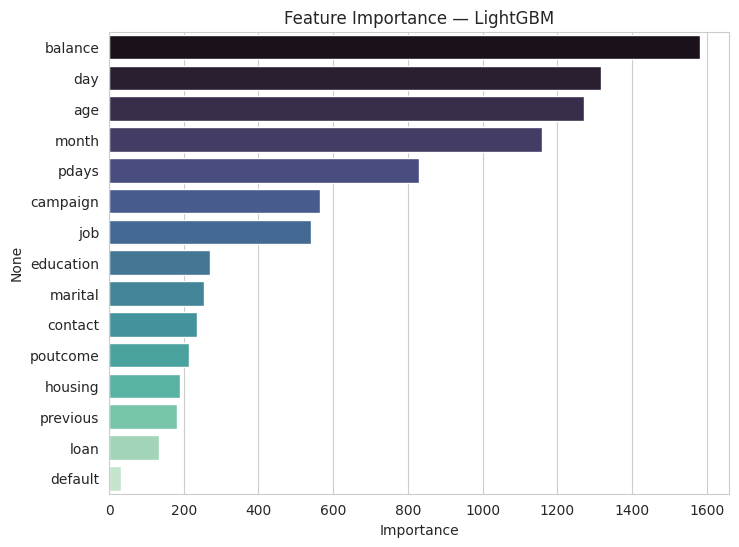

balance      1581
day          1318
age          1272
month        1159
pdays         829
campaign      566
job           542
education     271
marital       254
contact       235
poutcome      213
housing       190
previous      182
loan          135
default        33
dtype: int32

In [13]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title(f'Feature Importance — {best_model_name}')
plt.xlabel('Importance')
plt.show()

importances

## 9. Conclusion

- We predicted whether a bank customer would subscribe to a **term deposit** using demographic, financial, and campaign-history features.
- We identified and **removed `duration`** to prevent data leakage, ensuring the model reflects a realistic, pre-call prediction scenario.
- The target was **imbalanced (~88% No / ~12% Yes)**, so we used `class_weight`/`scale_pos_weight` and evaluated models with **ROC-AUC, Precision, Recall, and F1** rather than accuracy alone.
- Among Random Forest, Gradient Boosting, XGBoost, and LightGBM, the **best model achieved a strong ROC-AUC score** (see comparison table above), showing tree-based ensembles handle this mixed categorical/numerical, imbalanced dataset well.
- **Top predictive features** typically include `poutcome` (previous campaign outcome), `month`, `age`, `balance`, and `housing` loan status — suggesting marketing teams should prioritize customers with positive past campaign responses and tailor outreach by contact month.
- **Next steps:** hyperparameter tuning (GridSearch/Optuna), SMOTE-based oversampling, and threshold tuning to optimize for business cost of false negatives vs false positives.